In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
from scipy.interpolate import interp1d
from scipy.optimize import brentq

plt.rcParams.update({
    "font.size": 14,                 # global font size
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (5, 4),
})


In [12]:

# ==========================================
# 1. Helper functions
# ==========================================


def discover_temperature_dirs(base_dir):
    """Scan T_* subdirs, parse temperature, and return sorted entries."""
    raw_entries = []
    for dir_name in os.listdir(base_dir):
        if not dir_name.startswith("T_"):
            continue

        data_dir = os.path.join(base_dir, dir_name)
        if not os.path.isdir(data_dir):
            continue

        temp_str = dir_name[2:]
        try:
            T = float(temp_str)
        except ValueError:
            print(f"Skip non-numeric temperature folder: {dir_name}")
            continue

        raw_entries.append((T, dir_name, data_dir))

    if len(raw_entries) == 0:
        raise RuntimeError(
            f"No valid temperature directories found under {base_dir}. "
            "Expected names like T_0.003 or T_0.0003."
        )

    # If duplicate temperatures exist, keep lexicographically smallest folder name.
    temp_map = {}
    for T, dir_name, data_dir in raw_entries:
        if T in temp_map:
            old_name, _ = temp_map[T]
            if dir_name < old_name:
                print(f"Warning: duplicate T={T:g}, use {dir_name}, skip {old_name}")
                temp_map[T] = (dir_name, data_dir)
            else:
                print(f"Warning: duplicate T={T:g}, use {old_name}, skip {dir_name}")
        else:
            temp_map[T] = (dir_name, data_dir)

    temp_entries = [(T, info[0], info[1]) for T, info in temp_map.items()]
    temp_entries.sort(key=lambda x: x[0])
    return temp_entries


def read_opt_cond(data_dir, filename="spectra_opt_cond.csv"):
    file_path = os.path.join(data_dir, filename)
    if not os.path.exists(file_path):
        print(f"Warning: File not found {file_path}")
        return None

    df = pd.read_csv(file_path)
    if df.empty:
        print(f"Warning: Empty file {file_path}")
        return None

    required_cols = {"omega", "Re_Sigma"}
    if not required_cols.issubset(df.columns):
        print(f"Warning: Missing required columns in {file_path}: {required_cols - set(df.columns)}")
        return None

    df = df.sort_values("omega")
    return df


def load_summary(base_dir="./"):
    summary_path = os.path.join(base_dir, "summary_all.csv")
    if not os.path.exists(summary_path):
        return pd.DataFrame()
    return pd.read_csv(summary_path).sort_values("T")


def estimate_tc_from_summary(summary_df, rho_col="Superfluid_Stiffness_mean"):
    if summary_df.empty or rho_col not in summary_df.columns or len(summary_df) < 2:
        return np.nan
    T = summary_df["T"].to_numpy(dtype=float)
    diff = summary_df[rho_col].to_numpy(dtype=float) - (2.0 / np.pi) * T
    finite = np.isfinite(T) & np.isfinite(diff)
    T = T[finite]
    diff = diff[finite]
    if len(T) < 2:
        return np.nan
    for i in range(len(T) - 1):
        if diff[i] == 0:
            return float(T[i])
        if diff[i] * diff[i + 1] <= 0:
            return float(T[i] - diff[i] * (T[i + 1] - T[i]) / (diff[i + 1] - diff[i]))
    return np.nan


def compute_temperature_floor(Tc, factor=0.5):
    if np.isfinite(Tc):
        return float(factor * Tc)
    return -np.inf


def build_dc_comparison_df(summary_df, dc_df, Tc=np.nan, temperature_floor_factor=0.5):
    if summary_df is None or summary_df.empty:
        kubo_df = pd.DataFrame(columns=["T", "sigma_dc_kubo", "sigma_dc_kubo_err"])
    else:
        kubo_df = pd.DataFrame({"T": summary_df["T"].to_numpy(dtype=float)})
        kubo_df["sigma_dc_kubo"] = (
            summary_df["DC_Conductivity_mean"].to_numpy(dtype=float)
            if "DC_Conductivity_mean" in summary_df.columns
            else np.nan
        )
        kubo_df["sigma_dc_kubo_err"] = (
            summary_df["DC_Conductivity_err"].to_numpy(dtype=float)
            if "DC_Conductivity_err" in summary_df.columns
            else np.nan
        )

    if dc_df is None or len(dc_df) == 0:
        optical_df = pd.DataFrame(columns=["T", "sigma_dc_optical", "R_dc_optical"])
    else:
        optical_df = (
            dc_df[["T", "sigma_dc", "R_dc"]]
            .rename(columns={"sigma_dc": "sigma_dc_optical", "R_dc": "R_dc_optical"})
            .copy()
        )

    compare_df = pd.merge(kubo_df, optical_df, on="T", how="outer").sort_values("T").reset_index(drop=True)

    sigma_kubo = compare_df["sigma_dc_kubo"].to_numpy(dtype=float)
    sigma_kubo_err = compare_df["sigma_dc_kubo_err"].to_numpy(dtype=float)
    sigma_optical = compare_df["sigma_dc_optical"].to_numpy(dtype=float)
    R_optical = compare_df["R_dc_optical"].to_numpy(dtype=float)

    valid_kubo = np.isfinite(sigma_kubo) & (sigma_kubo > 0.0)
    compare_df["R_dc_kubo"] = np.nan
    compare_df.loc[valid_kubo, "R_dc_kubo"] = 1.0 / sigma_kubo[valid_kubo]

    compare_df["R_dc_kubo_err"] = np.nan
    valid_kubo_err = valid_kubo & np.isfinite(sigma_kubo_err)
    compare_df.loc[valid_kubo_err, "R_dc_kubo_err"] = (
        sigma_kubo_err[valid_kubo_err] / (sigma_kubo[valid_kubo_err] ** 2)
    )

    compare_df["sigma_rel_diff"] = np.nan
    overlap_sigma = valid_kubo & np.isfinite(sigma_optical)
    compare_df.loc[overlap_sigma, "sigma_rel_diff"] = (
        sigma_optical[overlap_sigma] - sigma_kubo[overlap_sigma]
    ) / sigma_kubo[overlap_sigma]

    compare_df["R_rel_diff"] = np.nan
    overlap_R = np.isfinite(compare_df["R_dc_kubo"].to_numpy(dtype=float)) & np.isfinite(R_optical)
    compare_df.loc[overlap_R, "R_rel_diff"] = (
        R_optical[overlap_R] - compare_df.loc[overlap_R, "R_dc_kubo"].to_numpy(dtype=float)
    ) / compare_df.loc[overlap_R, "R_dc_kubo"].to_numpy(dtype=float)

    temperature_floor = compute_temperature_floor(Tc, factor=temperature_floor_factor)
    compare_df["temperature_floor"] = temperature_floor
    compare_df["keep_for_resistivity_plot"] = np.isfinite(compare_df["T"].to_numpy(dtype=float)) & (
        compare_df["T"].to_numpy(dtype=float) >= temperature_floor
    )

    return compare_df


In [13]:
# ==========================================
# 2. Main loop
# ==========================================

base_dir = "./"  # set to your data root if needed
temp_entries = discover_temperature_dirs(base_dir)
T_list = np.array([T for T, _, _ in temp_entries], dtype=float)

spectra = []

print(f"Starting optical-conductivity analysis for {len(T_list)} temperatures...")

for T, dir_name, data_dir in temp_entries:
    print(f"Processing {dir_name}...", end="\r")

    df = read_opt_cond(data_dir)
    if df is None:
        continue

    omega = df["omega"].to_numpy()
    sigma = df["Re_Sigma"].to_numpy()
    sigma_err = df["Error"].to_numpy() if "Error" in df.columns else None

    spectra.append({
        "T": T,
        "dir_name": dir_name,
        "omega": omega,
        "sigma": sigma,
        "sigma_err": sigma_err,
    })

print("\nAnalysis complete.")


Starting optical-conductivity analysis for 7 temperatures...
Processing T_0.050...
Analysis complete.


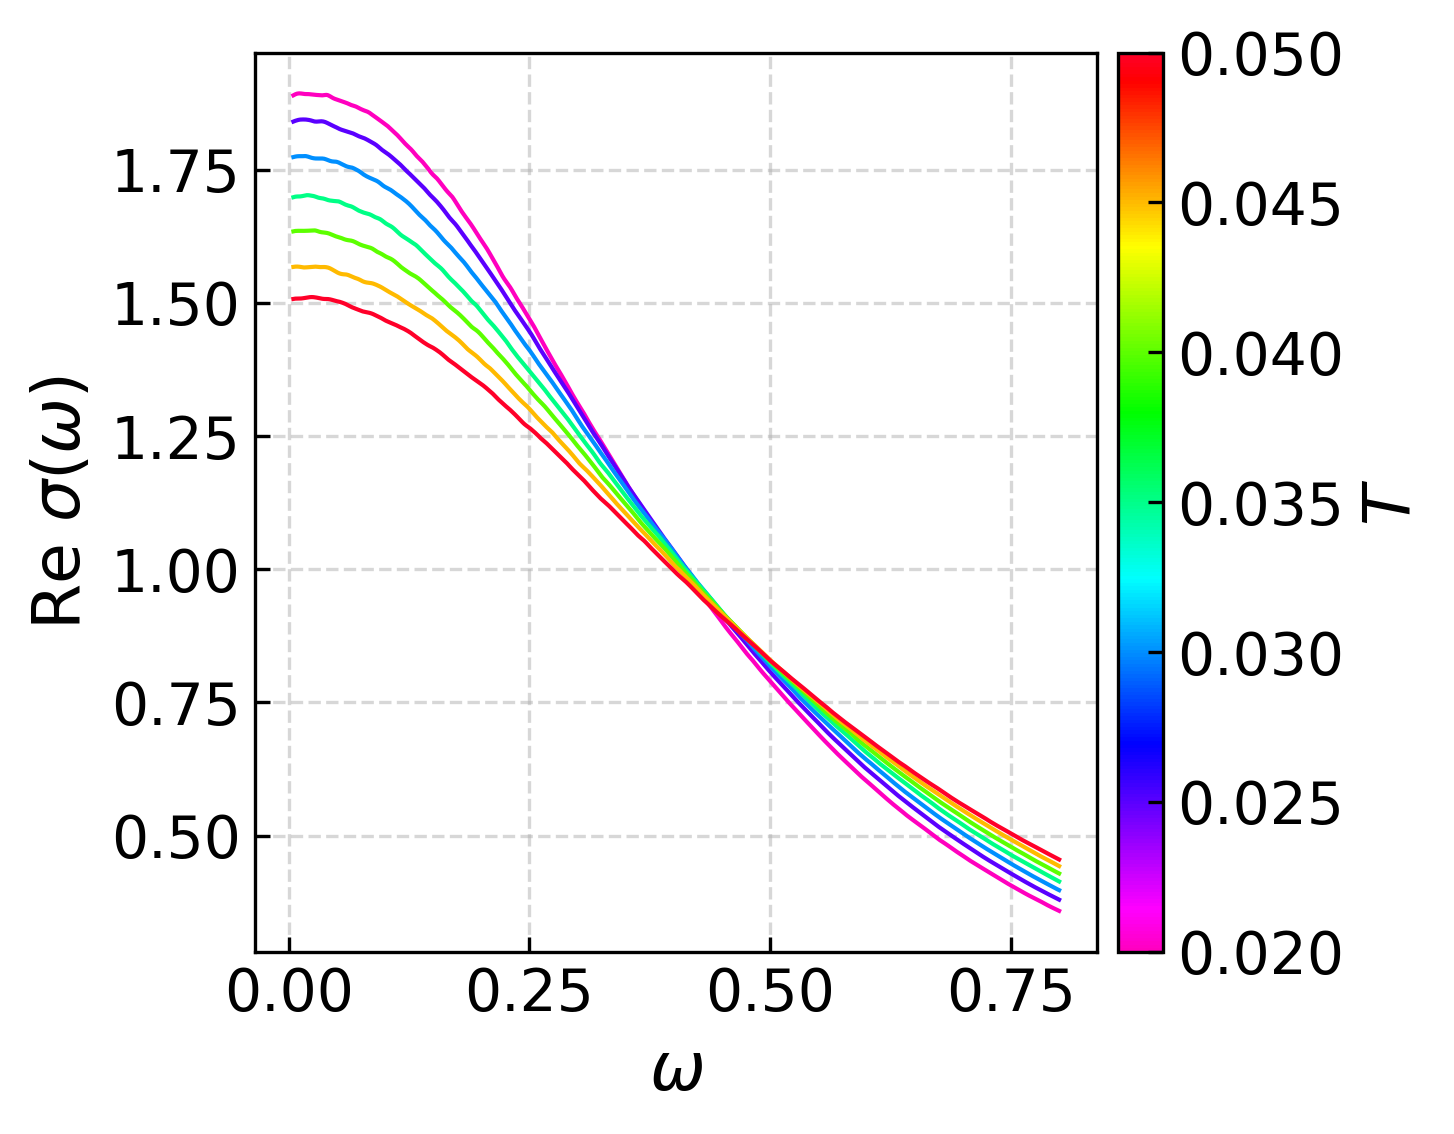

In [14]:
# ==========================================
# 3. Re sigma(omega) vs omega for different T
# ==========================================

if len(spectra) == 0:
    raise RuntimeError("No valid optical-conductivity data found.")

T_used = np.array([spec["T"] for spec in spectra], dtype=float)
# cmap = plt.cm.plasma
cmap = plt.cm.gist_rainbow_r

if len(T_used) > 1 and np.max(T_used) > np.min(T_used):
    norm = mcolors.Normalize(vmin=np.min(T_used), vmax=np.max(T_used))
else:
    t0 = float(T_used[0])
    norm = mcolors.Normalize(vmin=t0 - 1e-12, vmax=t0 + 1e-12)

fig, ax = plt.subplots(dpi=300)

for spec in spectra:
    color = cmap(norm(spec["T"]))
    ax.plot(spec["omega"], spec["sigma"], color=color, linewidth=1)

    # err = spec["sigma_err"]
    # if err is not None and len(err) == len(spec["sigma"]):
    #     mask = np.isfinite(spec["sigma"]) & np.isfinite(err)
    #     if np.any(mask):
    #         ax.fill_between(
    #             spec["omega"][mask],
    #             spec["sigma"][mask] - err[mask],
    #             spec["sigma"][mask] + err[mask],
    #             color=color,
    #             alpha=0.2,
    #         )

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$T$")

ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"Re $\sigma(\omega)$")
# ax.set_xlim(0,0.2)
# ax.set_ylim(2.1,3.4)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


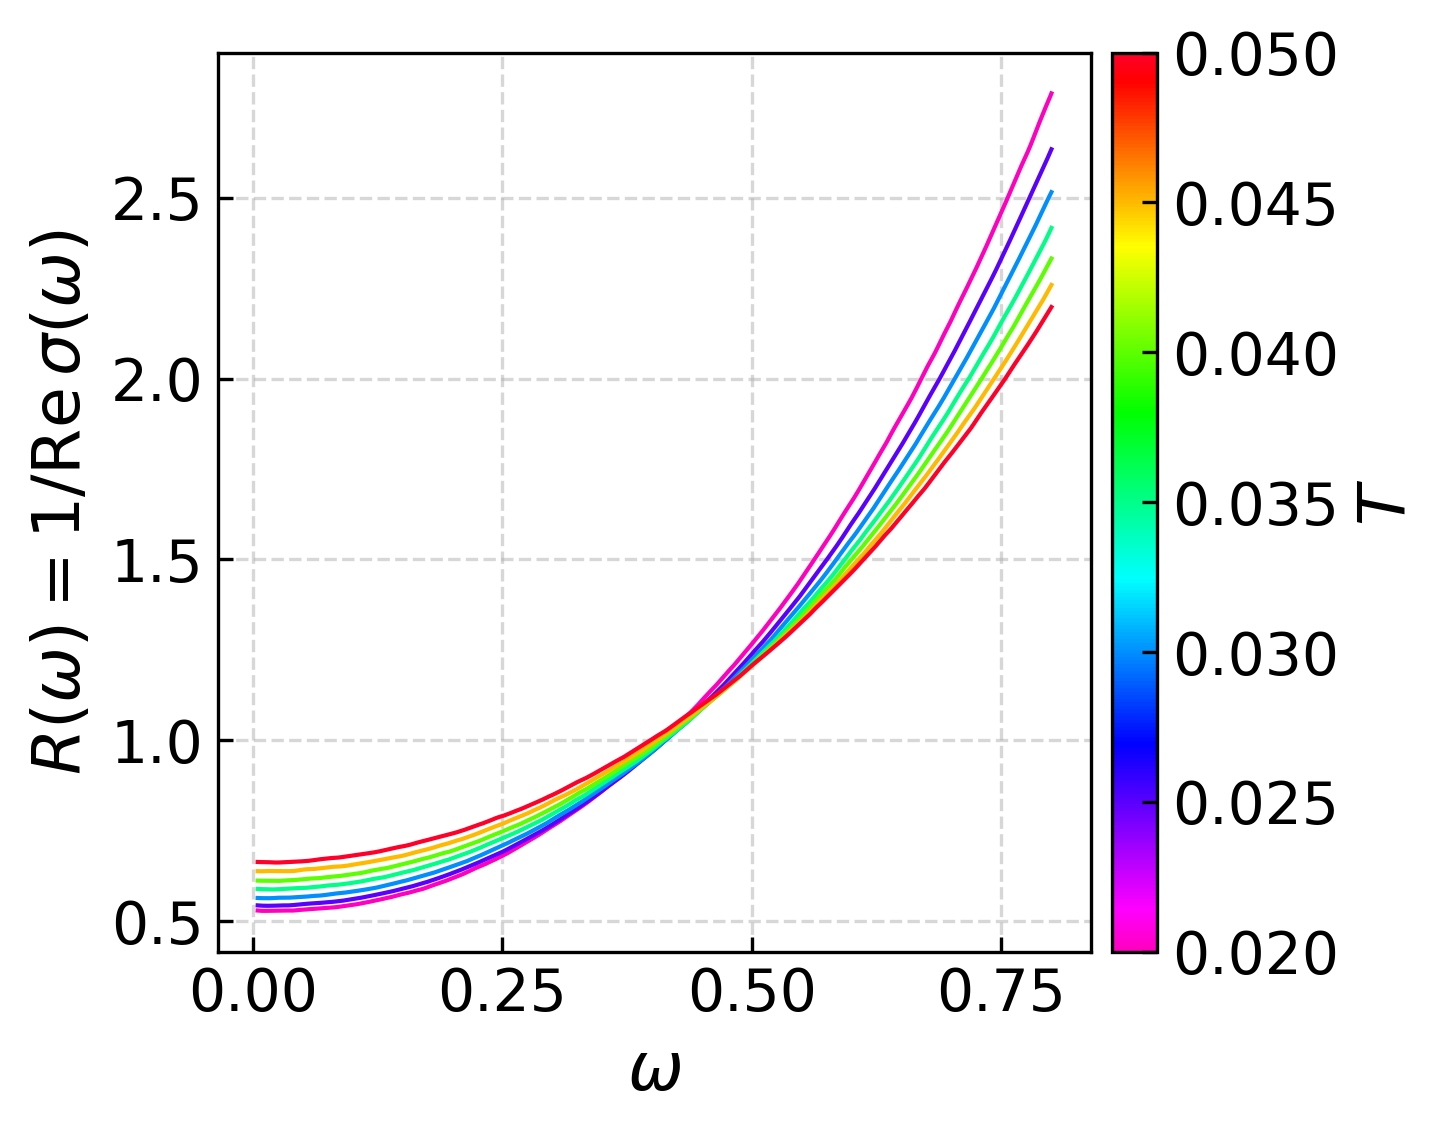

In [15]:
# ==========================================
# 4. Resistivity proxy R(omega)=1/Re sigma(omega) for different T
# ==========================================

if len(spectra) == 0:
    raise RuntimeError("No valid optical-conductivity data found.")

T_used = np.array([spec["T"] for spec in spectra], dtype=float)
# cmap = plt.cm.plasma
cmap = plt.cm.gist_rainbow_r

if len(T_used) > 1 and np.max(T_used) > np.min(T_used):
    norm = mcolors.Normalize(vmin=np.min(T_used), vmax=np.max(T_used))
else:
    t0 = float(T_used[0])
    norm = mcolors.Normalize(vmin=t0 - 1e-12, vmax=t0 + 1e-12)

fig, ax = plt.subplots(dpi=300)

for spec in spectra:
    omega = spec["omega"]
    sigma = spec["sigma"]
    color = cmap(norm(spec["T"]))

    mask = np.isfinite(omega) & np.isfinite(sigma) & (np.abs(sigma) > 1e-12)
    if not np.any(mask):
        continue

    R = np.full_like(sigma, np.nan, dtype=float)
    R[mask] = 1.0 / sigma[mask]
    ax.plot(omega[mask], R[mask], color=color, linewidth=1)

    # err = spec["sigma_err"]
    # if err is not None and len(err) == len(sigma):
    #     err = np.asarray(err)
    #     mask_err = mask & np.isfinite(err)
    #     if np.any(mask_err):
    #         R_err = np.full_like(sigma, np.nan, dtype=float)
    #         R_err[mask_err] = np.abs(err[mask_err] / (sigma[mask_err] ** 2))
    #         ax.fill_between(
    #             omega[mask_err],
    #             R[mask_err] - R_err[mask_err],
    #             R[mask_err] + R_err[mask_err],
    #             color=color,
    #             alpha=0.2,
    #         )

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$T$")

ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$R(\omega)=1/\mathrm{Re}\,\sigma(\omega)$")
# ax.set_xlim(0,0.2)
# ax.set_ylim(0.28,0.48)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [16]:
# ==========================================
# 5. DC extrapolation (Method 1 only) + auto omega_max selection
# ==========================================

omega_fit_max_manual = 0.03
auto_select_omega_fit_max = True
omega_fit_candidates = np.round(np.arange(0.02, 0.101, 0.005), 3)

min_fit_points = 8
use_weighted_fit = False  # True uses Error column as 1/error weights

# Auto-selection hyperparameters
min_valid_ratio = 0.95
stability_tol = 2.5e-4   # median relative drift of sigma0 between neighboring windows
drift_weight = 2.0       # score = median_rel_rmse + drift_weight * median_rel_drift_prev


def extrapolate_w2_to_zero(omega, y, yerr=None, omega_max=0.03, min_points=8, use_weights=False):
    """Fit y(omega)=y0+a*omega^2 on low-frequency points and return y0 and fit diagnostics."""
    omega = np.asarray(omega, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(omega) & np.isfinite(y) & (omega >= 0.0) & (omega <= omega_max)

    weights = None
    if use_weights and (yerr is not None):
        yerr = np.asarray(yerr, dtype=float)
        mask = mask & np.isfinite(yerr) & (yerr > 0.0)

    if np.count_nonzero(mask) < min_points:
        return None

    omega_fit = omega[mask]
    y_fit = y[mask]
    x_fit = omega_fit ** 2

    if use_weights and (yerr is not None):
        weights = 1.0 / np.maximum(yerr[mask], 1e-12)

    coeff = np.polyfit(x_fit, y_fit, deg=1, w=weights)
    slope = float(coeff[0])
    y0 = float(coeff[1])

    y_pred = slope * x_fit + y0
    rmse = float(np.sqrt(np.mean((y_fit - y_pred) ** 2)))
    rel_rmse = rmse / max(abs(y0), 1e-12)

    omega_line = np.linspace(0.0, omega_max, 200)
    y_line = slope * (omega_line ** 2) + y0

    return {
        "y0": y0,
        "slope": slope,
        "n_points": int(len(omega_fit)),
        "rmse": rmse,
        "rel_rmse": rel_rmse,
        "omega_fit": omega_fit,
        "y_fit": y_fit,
        "omega_line": omega_line,
        "y_line": y_line,
    }


def scan_omega_fit_max(spectra, omega_candidates, min_points, use_weights, min_valid_ratio, stability_tol, drift_weight):
    """Scan candidate omega_max and choose a stable/accurate window globally over all temperatures."""
    rows = []
    sigma0_map = {}

    for omega_max in omega_candidates:
        sigma0_this = {}
        rel_rmse_list = []
        npt_list = []

        for spec in spectra:
            T = float(spec["T"])
            omega = np.asarray(spec["omega"], dtype=float)
            sigma = np.asarray(spec["sigma"], dtype=float)
            sigma_err = spec.get("sigma_err", None)

            fit_sigma = extrapolate_w2_to_zero(
                omega,
                sigma,
                yerr=sigma_err,
                omega_max=float(omega_max),
                min_points=min_points,
                use_weights=use_weights,
            )

            if fit_sigma is None:
                continue

            sigma0 = fit_sigma["y0"]
            if (not np.isfinite(sigma0)) or (sigma0 <= 0.0):
                continue

            sigma0_this[T] = sigma0
            rel_rmse_list.append(fit_sigma["rel_rmse"])
            npt_list.append(fit_sigma["n_points"])

        sigma0_map[float(omega_max)] = sigma0_this
        valid_count = len(sigma0_this)

        rows.append(
            {
                "omega_max": float(omega_max),
                "valid_count": valid_count,
                "valid_ratio": valid_count / max(len(spectra), 1),
                "median_rel_rmse": float(np.median(rel_rmse_list)) if len(rel_rmse_list) > 0 else np.nan,
                "p90_rel_rmse": float(np.percentile(rel_rmse_list, 90)) if len(rel_rmse_list) > 0 else np.nan,
                "min_fit_points_used": int(np.min(npt_list)) if len(npt_list) > 0 else np.nan,
                "median_fit_points_used": float(np.median(npt_list)) if len(npt_list) > 0 else np.nan,
            }
        )

    diag_df = pd.DataFrame(rows)

    drift_vals = []
    omega_list = diag_df["omega_max"].to_numpy(dtype=float)
    for i, omega_max in enumerate(omega_list):
        if i == 0:
            drift_vals.append(np.nan)
            continue

        omega_prev = omega_list[i - 1]
        map_now = sigma0_map[float(omega_max)]
        map_prev = sigma0_map[float(omega_prev)]

        common_T = sorted(set(map_now.keys()).intersection(set(map_prev.keys())))
        if len(common_T) == 0:
            drift_vals.append(np.nan)
            continue

        rel_drift = [
            abs(map_now[T] - map_prev[T]) / max(abs(map_prev[T]), 1e-12)
            for T in common_T
        ]
        drift_vals.append(float(np.median(rel_drift)))

    diag_df["median_rel_drift_prev"] = drift_vals

    drift_fill = diag_df["median_rel_drift_prev"].copy()
    if np.all(~np.isfinite(drift_fill)):
        drift_fill = pd.Series(np.zeros(len(diag_df)), index=diag_df.index, dtype=float)
    else:
        drift_fill = drift_fill.fillna(float(np.nanmax(drift_fill.to_numpy(dtype=float))))

    diag_df["score"] = diag_df["median_rel_rmse"] + drift_weight * drift_fill

    eligible = (
        (diag_df["valid_ratio"] >= min_valid_ratio)
        & np.isfinite(diag_df["score"])
        & (
            (diag_df["median_rel_drift_prev"] <= stability_tol)
            | (~np.isfinite(diag_df["median_rel_drift_prev"]))
        )
    )

    if np.any(eligible):
        best_idx = diag_df.loc[eligible, "score"].idxmin()
    else:
        valid_only = np.isfinite(diag_df["score"])
        if np.any(valid_only):
            best_idx = diag_df.loc[valid_only, "score"].idxmin()
        else:
            return float(omega_fit_max_manual), diag_df

    return float(diag_df.loc[best_idx, "omega_max"]), diag_df


if len(spectra) == 0:
    raise RuntimeError("No valid optical-conductivity data found.")

if auto_select_omega_fit_max:
    omega_fit_max, omega_scan_df = scan_omega_fit_max(
        spectra=spectra,
        omega_candidates=omega_fit_candidates,
        min_points=min_fit_points,
        use_weights=use_weighted_fit,
        min_valid_ratio=min_valid_ratio,
        stability_tol=stability_tol,
        drift_weight=drift_weight,
    )
else:
    omega_fit_max = float(omega_fit_max_manual)
    omega_scan_df = pd.DataFrame()

print(f"Selected omega_fit_max = {omega_fit_max:.3f} (auto={auto_select_omega_fit_max})")

# Method 1 only: fit sigma(omega) -> sigma_dc, then R_dc = 1/sigma_dc

dc_rows = []
fit_store = {}

for spec in spectra:
    T = float(spec["T"])
    omega = np.asarray(spec["omega"], dtype=float)
    sigma = np.asarray(spec["sigma"], dtype=float)
    sigma_err = spec.get("sigma_err", None)

    fit_sigma = extrapolate_w2_to_zero(
        omega,
        sigma,
        yerr=sigma_err,
        omega_max=omega_fit_max,
        min_points=min_fit_points,
        use_weights=use_weighted_fit,
    )

    if fit_sigma is None:
        print(f"Skip T={T:g}: not enough points for sigma-fit in [0, {omega_fit_max:.3f}]")
        continue

    sigma_dc = fit_sigma["y0"]
    if (not np.isfinite(sigma_dc)) or (sigma_dc <= 0.0):
        print(f"Skip T={T:g}: invalid sigma_dc={sigma_dc}")
        continue

    R_dc = 1.0 / sigma_dc

    dc_rows.append(
        {
            "T": T,
            "sigma_dc": sigma_dc,
            "R_dc": R_dc,
            "sigma_fit_rmse": fit_sigma["rmse"],
            "sigma_fit_rel_rmse": fit_sigma["rel_rmse"],
            "n_fit_points": fit_sigma["n_points"],
        }
    )

    fit_store[T] = {"fit_sigma": fit_sigma}

dc_df = pd.DataFrame(dc_rows).sort_values("T").reset_index(drop=True)
if len(dc_df) == 0:
    raise RuntimeError("No valid dc extrapolation result.")

print(f"Built dc extrapolation for {len(dc_df)} temperatures.")
print("Median sigma-fit relative RMSE:", float(np.median(dc_df["sigma_fit_rel_rmse"])))
dc_df.head()


Selected omega_fit_max = 0.040 (auto=True)
Built dc extrapolation for 7 temperatures.
Median sigma-fit relative RMSE: 0.0005287591619669993


,T,sigma_dc,R_dc,sigma_fit_rmse,sigma_fit_rel_rmse,n_fit_points
0,0.020,1.892260,0.528469,0.000755,0.000399,36
1,0.025,1.843566,0.542427,0.001105,0.000600,36
2,0.030,1.775384,0.563259,0.000797,0.000449,36
3,0.035,1.701404,0.587750,0.001477,0.000868,36
4,0.040,1.635851,0.611303,0.000865,0.000529,36


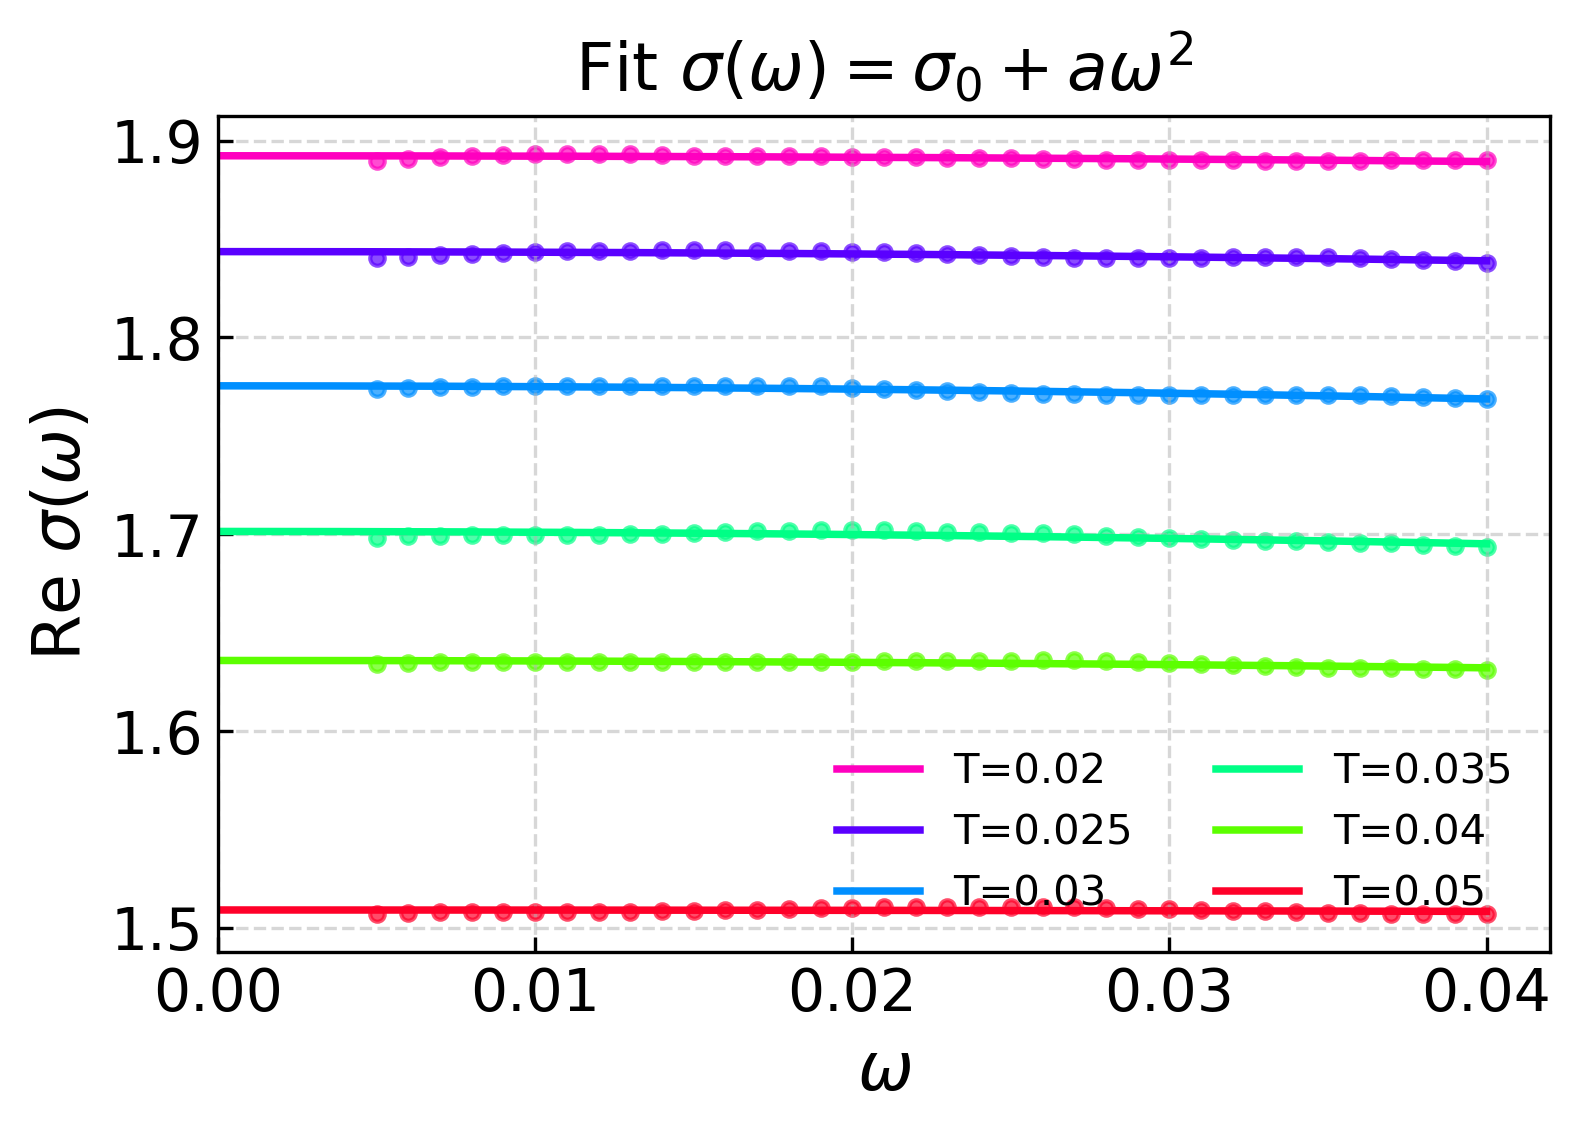

In [17]:
# ==========================================
# 6. Low-frequency sigma-fit check (sample temperatures)
# ==========================================

if len(dc_df) == 0:
    raise RuntimeError("No valid dc extrapolation result.")

n_show = 6
pick_idx = np.unique(np.linspace(0, len(dc_df) - 1, n_show, dtype=int))
T_show = dc_df.loc[pick_idx, "T"].to_numpy(dtype=float)

cmap_fit = plt.cm.gist_rainbow_r
if len(dc_df) > 1 and dc_df["T"].max() > dc_df["T"].min():
    norm_fit = mcolors.Normalize(vmin=dc_df["T"].min(), vmax=dc_df["T"].max())
else:
    t0 = float(dc_df["T"].iloc[0])
    norm_fit = mcolors.Normalize(vmin=t0 - 1e-12, vmax=t0 + 1e-12)

fig, ax = plt.subplots(figsize=(5.5, 4), dpi=300)

for T in T_show:
    color = cmap_fit(norm_fit(T))
    fit_sigma = fit_store[float(T)]["fit_sigma"]

    ax.scatter(fit_sigma["omega_fit"], fit_sigma["y_fit"], s=12, color=color, alpha=0.7)
    ax.plot(fit_sigma["omega_line"], fit_sigma["y_line"], color=color, linewidth=1.8, label=f"T={T:g}")

ax.set_title(r"Fit $\sigma(\omega)=\sigma_0 + a\omega^2$")
ax.set_xlim(0.0, omega_fit_max * 1.05)
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"Re $\sigma(\omega)$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(frameon=False, fontsize=10, ncol=2)

plt.tight_layout()
plt.show()


In [18]:

summary_df = load_summary(base_dir)
Tc = estimate_tc_from_summary(summary_df)

temperature_floor_factor = 0.8
temperature_floor = compute_temperature_floor(Tc, factor=temperature_floor_factor)

dc_compare_df = build_dc_comparison_df(
    summary_df=summary_df,
    dc_df=dc_df if "dc_df" in globals() else pd.DataFrame(),
    Tc=Tc,
    temperature_floor_factor=temperature_floor_factor,
)

pd.DataFrame(
    {
        "Tc": [Tc],
        "temperature_floor_factor": [temperature_floor_factor],
        "temperature_floor": [temperature_floor if np.isfinite(temperature_floor) else np.nan],
    }
)


,Tc,temperature_floor_factor,temperature_floor
0,0.02699,0.8,0.021592


summary_all.csv / DC_Conductivity_mean: Kubo-Greenwood dc conductivity.
dc_df / sigma_dc: low-frequency optical extrapolation of Re sigma(omega) to omega -> 0.
sigma_dc overlap: median |optical/Kubo - 1| = 8.644e-02, max = 8.810e-02
R_dc overlap (after temperature cutoff): median |optical/Kubo - 1| = 7.945e-02, max = 8.011e-02


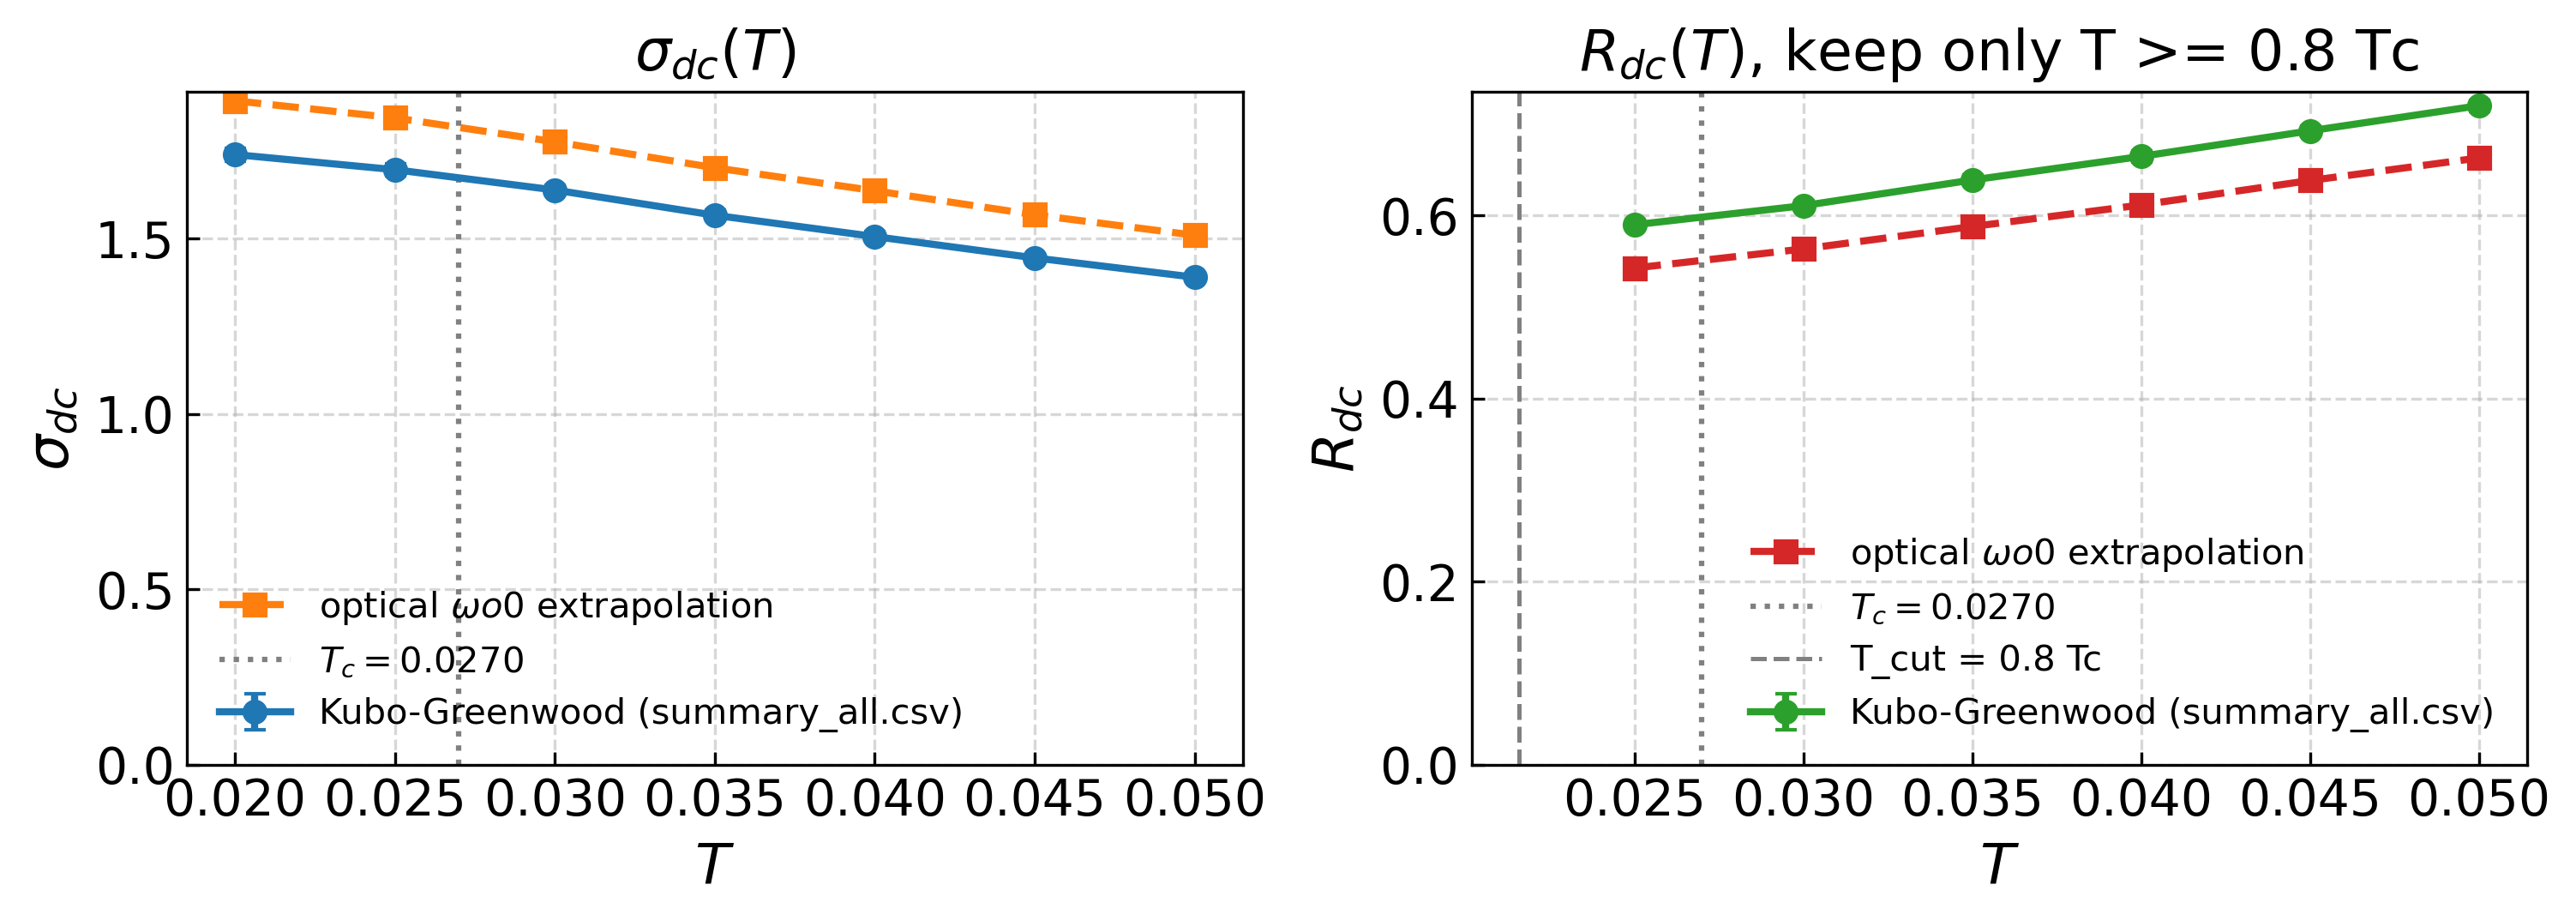

,T,sigma_dc_kubo,sigma_dc_optical,sigma_rel_diff,R_dc_kubo,R_dc_optical,R_rel_diff,keep_for_resistivity_plot
0,0.020,1.739049,1.892260,0.088100,0.575027,0.528469,-0.080967,False
1,0.025,1.695879,1.843566,0.087086,0.589665,0.542427,-0.080110,True
2,0.030,1.637941,1.775384,0.083912,0.610523,0.563259,-0.077416,True
3,0.035,1.566030,1.701404,0.086444,0.638558,0.587750,-0.079566,True
4,0.040,1.505284,1.635851,0.086739,0.664327,0.611303,-0.079816,True
5,0.045,1.444501,1.567352,0.085047,0.692280,0.638019,-0.078381,True
6,0.050,1.389377,1.509099,0.086170,0.719747,0.662647,-0.079333,True


In [19]:

# ==========================================
# 7. DC conductivity/resistivity: Kubo vs optical extrapolation
# ==========================================

if "summary_df" not in globals() or summary_df.empty:
    summary_df = load_summary(base_dir)
if "Tc" not in globals():
    Tc = estimate_tc_from_summary(summary_df)
if "temperature_floor_factor" not in globals():
    temperature_floor_factor = 0.5
if "dc_compare_df" not in globals():
    dc_compare_df = build_dc_comparison_df(
        summary_df=summary_df,
        dc_df=dc_df if "dc_df" in globals() else pd.DataFrame(),
        Tc=Tc,
        temperature_floor_factor=temperature_floor_factor,
    )

plot_df = dc_compare_df.copy().sort_values("T").reset_index(drop=True)
temperature_floor = (
    float(plot_df["temperature_floor"].iloc[0])
    if len(plot_df) > 0 and "temperature_floor" in plot_df.columns
    else compute_temperature_floor(Tc, factor=temperature_floor_factor)
)

print("summary_all.csv / DC_Conductivity_mean: Kubo-Greenwood dc conductivity.")
print("dc_df / sigma_dc: low-frequency optical extrapolation of Re sigma(omega) to omega -> 0.")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8), dpi=300)

if plot_df.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "No dc conductivity data available", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
else:
    sigma_kubo_mask = (
        np.isfinite(plot_df["T"].to_numpy(dtype=float))
        & np.isfinite(plot_df["sigma_dc_kubo"].to_numpy(dtype=float))
        & (plot_df["sigma_dc_kubo"].to_numpy(dtype=float) > 0.0)
    )
    sigma_optical_mask = (
        np.isfinite(plot_df["T"].to_numpy(dtype=float))
        & np.isfinite(plot_df["sigma_dc_optical"].to_numpy(dtype=float))
        & (plot_df["sigma_dc_optical"].to_numpy(dtype=float) > 0.0)
    )

    axes[0].errorbar(
        plot_df.loc[sigma_kubo_mask, "T"],
        plot_df.loc[sigma_kubo_mask, "sigma_dc_kubo"],
        yerr=plot_df.loc[sigma_kubo_mask, "sigma_dc_kubo_err"],
        fmt="-o",
        capsize=3,
        color="tab:blue",
        label=r"Kubo-Greenwood (summary_all.csv)",
    )
    axes[0].plot(
        plot_df.loc[sigma_optical_mask, "T"],
        plot_df.loc[sigma_optical_mask, "sigma_dc_optical"],
        "--s",
        color="tab:orange",
        label=r"optical $\omega 	o 0$ extrapolation",
    )

    resistivity_window = plot_df["keep_for_resistivity_plot"].to_numpy(dtype=bool)
    R_kubo_mask = (
        resistivity_window
        & np.isfinite(plot_df["R_dc_kubo"].to_numpy(dtype=float))
        & (plot_df["R_dc_kubo"].to_numpy(dtype=float) > 0.0)
    )
    R_optical_mask = (
        resistivity_window
        & np.isfinite(plot_df["R_dc_optical"].to_numpy(dtype=float))
        & (plot_df["R_dc_optical"].to_numpy(dtype=float) > 0.0)
    )

    axes[1].errorbar(
        plot_df.loc[R_kubo_mask, "T"],
        plot_df.loc[R_kubo_mask, "R_dc_kubo"],
        yerr=plot_df.loc[R_kubo_mask, "R_dc_kubo_err"],
        fmt="-o",
        capsize=3,
        color="tab:green",
        label=r"Kubo-Greenwood (summary_all.csv)",
    )
    axes[1].plot(
        plot_df.loc[R_optical_mask, "T"],
        plot_df.loc[R_optical_mask, "R_dc_optical"],
        "--s",
        color="tab:red",
        label=r"optical $\omega 	o 0$ extrapolation",
    )

    for ax in axes:
        if np.isfinite(Tc):
            ax.axvline(x=Tc, color="gray", linestyle=":", linewidth=1.5, label=rf"$T_c={Tc:.4f}$")
        ax.set_xlabel(r"$T$")
        ax.set_ylim(bottom=0)
        ax.grid(True, linestyle="--", alpha=0.5)

    if np.isfinite(temperature_floor):
        axes[1].axvline(
            x=temperature_floor,
            color="gray",
            linestyle="--",
            linewidth=1.2,
            label=f"T_cut = {temperature_floor_factor:g} Tc",
        )
        axes[1].set_title(r"$R_{dc}(T)$" + f", keep only T >= {temperature_floor_factor:g} Tc")
    else:
        axes[1].set_title(r"$R_{dc}(T)$")

    axes[0].set_title(r"$\sigma_{dc}(T)$")
    axes[0].set_ylabel(r"$\sigma_{dc}$")
    axes[1].set_ylabel(r"$R_{dc}$")

    for ax in axes:
        ax.legend(loc="best", frameon=False, fontsize=10)

    overlap_sigma = sigma_kubo_mask & sigma_optical_mask
    if np.any(overlap_sigma):
        sigma_rel = np.abs(plot_df.loc[overlap_sigma, "sigma_rel_diff"].to_numpy(dtype=float))
        print(
            "sigma_dc overlap: "
            f"median |optical/Kubo - 1| = {np.nanmedian(sigma_rel):.3e}, "
            f"max = {np.nanmax(sigma_rel):.3e}"
        )

    overlap_R = R_kubo_mask & R_optical_mask
    if np.any(overlap_R):
        R_rel = np.abs(plot_df.loc[overlap_R, "R_rel_diff"].to_numpy(dtype=float))
        print(
            "R_dc overlap (after temperature cutoff): "
            f"median |optical/Kubo - 1| = {np.nanmedian(R_rel):.3e}, "
            f"max = {np.nanmax(R_rel):.3e}"
        )

plt.tight_layout()
plt.show()

compare_display_cols = [
    "T",
    "sigma_dc_kubo",
    "sigma_dc_optical",
    "sigma_rel_diff",
    "R_dc_kubo",
    "R_dc_optical",
    "R_rel_diff",
    "keep_for_resistivity_plot",
]
plot_df[compare_display_cols]


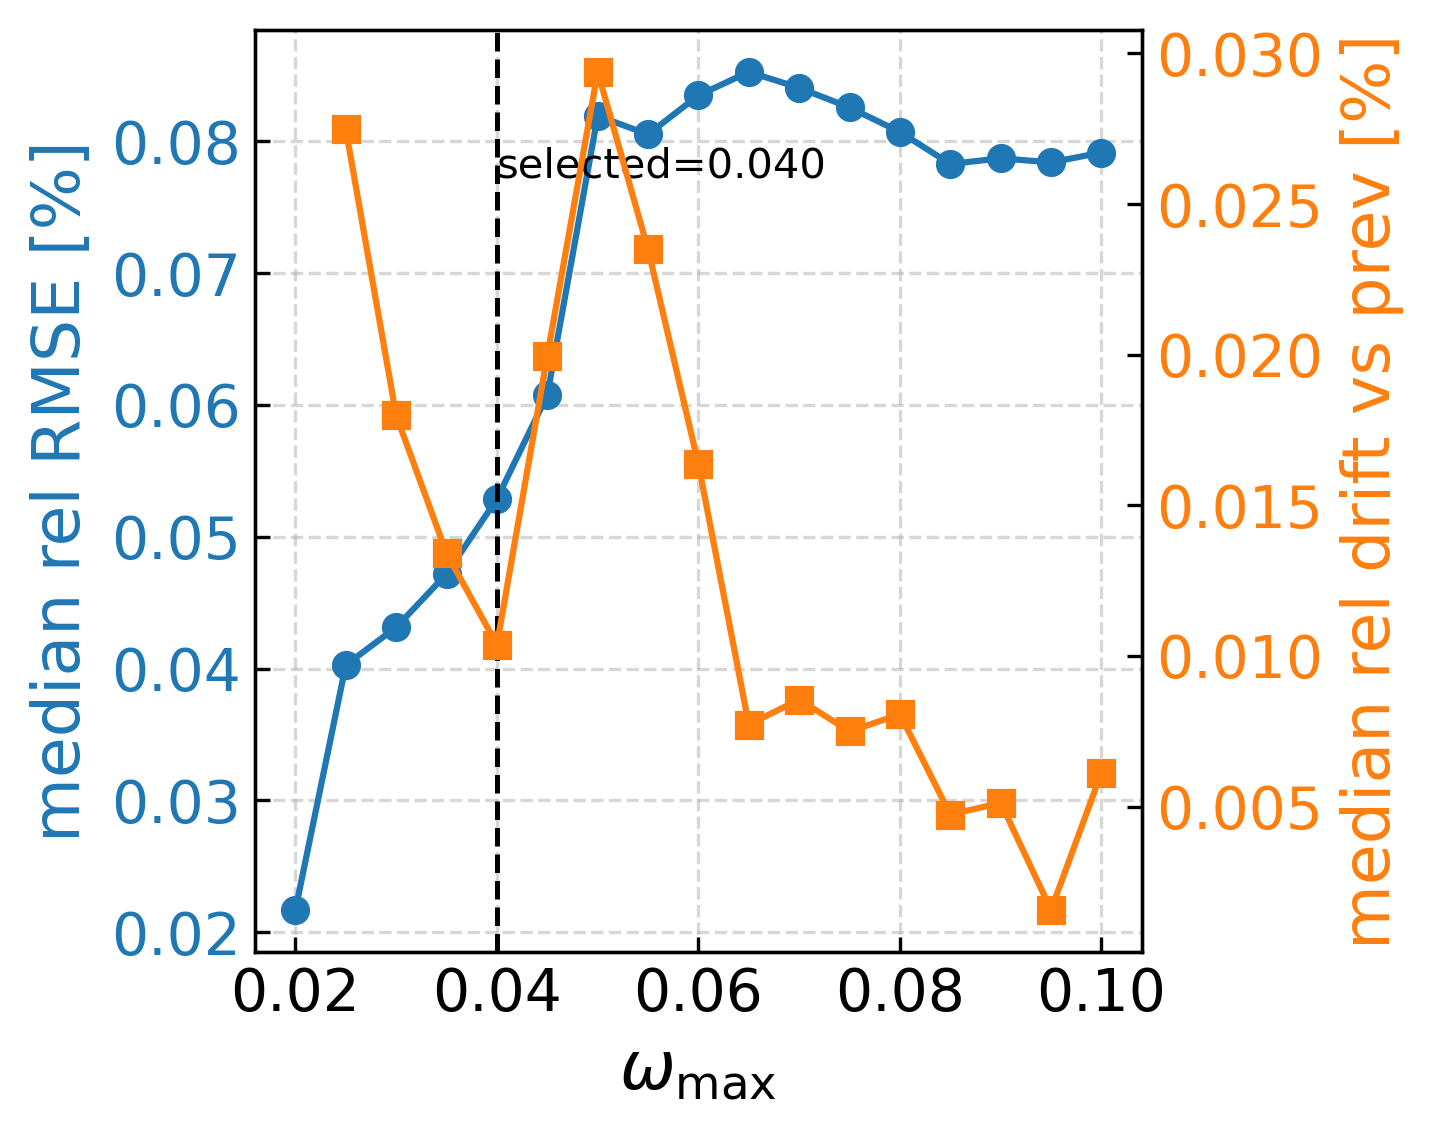

,T,sigma_dc,R_dc,sigma_fit_rel_rmse,n_fit_points
0,0.020,1.892260,0.528469,0.000399,36
1,0.025,1.843566,0.542427,0.000600,36
2,0.030,1.775384,0.563259,0.000449,36
3,0.035,1.701404,0.587750,0.000868,36
4,0.040,1.635851,0.611303,0.000529,36
5,0.045,1.567352,0.638019,0.000300,36
6,0.050,1.509099,0.662647,0.000793,36


In [20]:
if len(omega_scan_df) > 0:
    fig, ax1 = plt.subplots(dpi=300)

    ax1.plot(
        omega_scan_df["omega_max"],
        100.0 * omega_scan_df["median_rel_rmse"],
        marker="o",
        linewidth=1.5,
        color="tab:blue",
        label="median rel RMSE [%]",
    )
    ax1.set_xlabel(r"$\omega_{\max}$")
    ax1.set_ylabel("median rel RMSE [%]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(
        omega_scan_df["omega_max"],
        100.0 * omega_scan_df["median_rel_drift_prev"],
        marker="s",
        linewidth=1.5,
        color="tab:orange",
        label="median rel drift vs prev [%]",
    )
    ax2.set_ylabel("median rel drift vs prev [%]", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    ax1.axvline(omega_fit_max, color="black", linestyle="--", linewidth=1.2)
    ax1.text(
        omega_fit_max,
        ax1.get_ylim()[1] * 0.9,
        f"selected={omega_fit_max:.3f}",
        ha="left",
        va="top",
        fontsize=10,
    )

    plt.tight_layout()
    plt.show()

    display_cols = [
        "omega_max",
        "valid_count",
        "valid_ratio",
        "median_fit_points_used",
        "median_rel_rmse",
        "median_rel_drift_prev",
        "score",
    ]
    omega_scan_df[display_cols]


dc_df[["T", "sigma_dc", "R_dc", "sigma_fit_rel_rmse", "n_fit_points"]].head(10)
